# FaceMesh 랜드마크 추출 시각화

우리 Full_System 파이프라인의 **얼굴 랜드마크 추출**(YOLO-Face bbox → MediaPipe FaceMesh, 478점)을
실제 얼굴 프레임 위에 오버레이해서 몇 장 확인하는 노트북.

- 초록 점 = 추출된 478 랜드마크, 노란 박스 = YOLO-Face bbox
- 커널: `/data/shared/envs/scuppy/bin/python` (env `scuppy`)

## 1. 모듈 로드 (YOLO-Face + MediaPipe FaceMesh)

In [1]:
import sys, cv2, numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

ROOT = Path("/data/shared/scuppy/Full_System")
sys.path.insert(0, str(ROOT))
from full_dms_system.yolo_face_bbox_extractor import YoloFaceBBoxExtractor
from full_dms_system.mediapipe_facemesh_yolo import MediaPipeFaceMeshOnYoloCrop

DEVICE = 0
face_bbox = YoloFaceBBoxExtractor(model_path=str(ROOT/"Model/yolo_face.pt"),
                                  img_size=640, conf=0.25, iou=0.6, device=DEVICE)
facemesh  = MediaPipeFaceMeshOnYoloCrop(refine_landmarks=True, min_detection_confidence=0.3,
                                        pad_ratio=0.2, static_image_mode=True)
print("loaded YOLO-Face + MediaPipe FaceMesh")

loaded YOLO-Face + MediaPipe FaceMesh


## 2. 입력 얼굴 영상 선택

In [2]:
# 분석할 얼굴 영상 (필요시 교체)
FACE_VIDEO = "/data/shared/DMD/distraction/dmd/gZ/34/s1/gZ_34_s1_2019-04-08T12;25;28+02;00_ir_face.mp4"
N_IMAGES   = 6          # 보여줄 이미지 수
FRAME_STEP = 40         # 프레임 간격 (다양한 장면)
assert Path(FACE_VIDEO).exists(), FACE_VIDEO
cap=cv2.VideoCapture(FACE_VIDEO)
print("video frames:", int(cap.get(cv2.CAP_PROP_FRAME_COUNT)), "| size:",
      int(cap.get(cv2.CAP_PROP_FRAME_WIDTH)), "x", int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT)))
cap.release()

video frames: 8546 | size: 1280 x 720


W0000 00:00:1780316270.479691 2308337 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


## 3. 랜드마크 추출 + 오버레이

In [3]:
def overlay_landmarks(frame_bgr):
    """YOLO-Face bbox → MediaPipe FaceMesh → 478점/박스 오버레이. (vis, n_landmarks, detected)"""
    fb = face_bbox(frame_bgr)
    vis = frame_bgr.copy()
    if not fb.get("detected", False):
        return vis, 0, False
    bbox = fb["bbox"].astype(np.float32)
    mp = facemesh(frame_bgr, bbox, True)
    x1,y1,x2,y2 = [int(round(v)) for v in bbox]
    cv2.rectangle(vis,(x1,y1),(x2,y2),(0,255,255),2)               # 노란 bbox
    if not mp["detected"]:
        return vis, 0, True
    lm = mp["landmarks"]
    for x,y,_ in lm:
        cv2.circle(vis,(int(round(x)),int(round(y))),1,(0,255,0),-1)  # 초록 점
    return vis, int((lm[:,:2]!=0).any(1).sum()), True

# 검출된 프레임을 FRAME_STEP 간격으로 모아 N_IMAGES 장
cap=cv2.VideoCapture(FACE_VIDEO)
shots=[]; idx=0
while len(shots)<N_IMAGES:
    ok,fr=cap.read()
    if not ok: break
    if idx % FRAME_STEP == 0:
        vis,n,det = overlay_landmarks(fr)
        if det and n>0: shots.append((idx,vis,n))
    idx+=1
cap.release()
print(f"수집된 이미지: {len(shots)} (각 478 랜드마크 오버레이)")

/data/shared/envs/scuppy/lib/python3.12/site-packages/google/protobuf/symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '


수집된 이미지: 6 (각 478 랜드마크 오버레이)


## 4. 결과 이미지

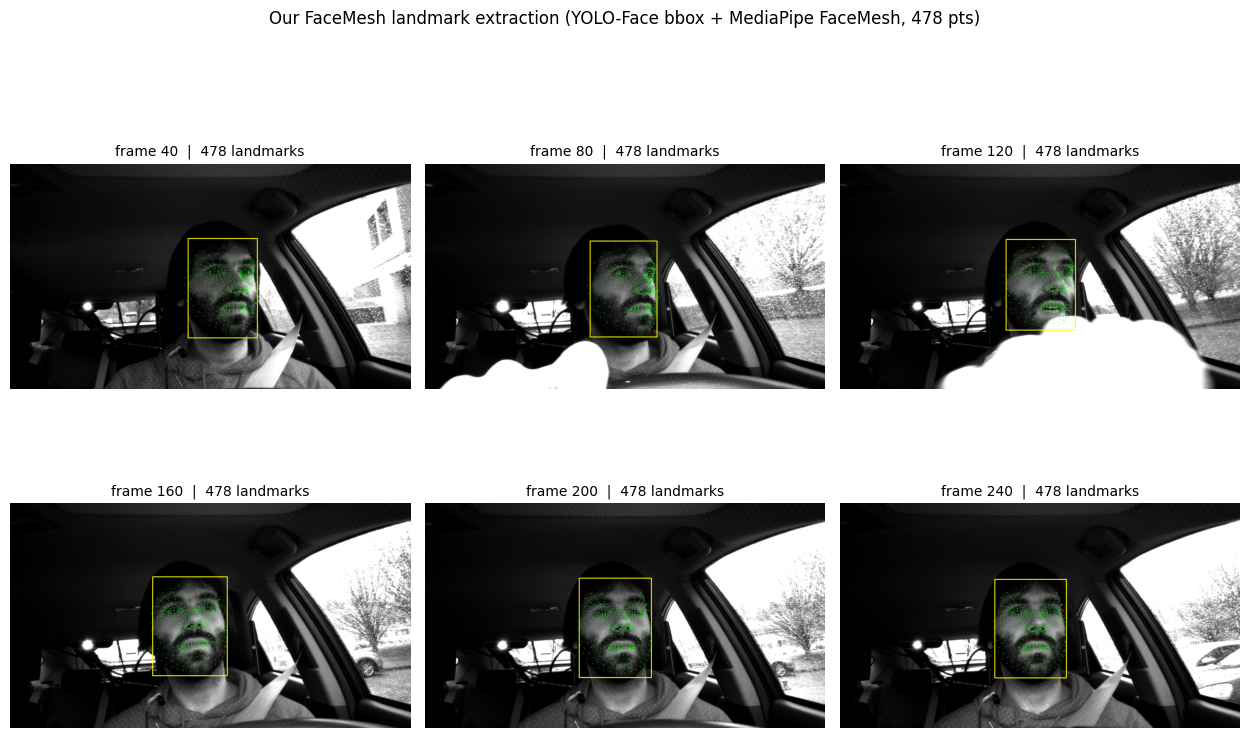

In [4]:
ncol=3; nrow=int(np.ceil(len(shots)/ncol))
fig,axes=plt.subplots(nrow,ncol,figsize=(ncol*4.2,nrow*4.2))
axes=np.atleast_1d(axes).ravel()
for ax in axes: ax.axis("off")
for ax,(fidx,vis,n) in zip(axes,shots):
    ax.imshow(cv2.cvtColor(vis,cv2.COLOR_BGR2RGB))
    ax.set_title(f"frame {fidx}  |  {n} landmarks",fontsize=10)
fig.suptitle("Our FaceMesh landmark extraction (YOLO-Face bbox + MediaPipe FaceMesh, 478 pts)",y=1.0)
plt.tight_layout(); plt.show()

## 5. (선택) 단일 프레임 확대 + 저장

saved 6 images → /data/shared/scuppy/Full_System/outputs/facemesh_view


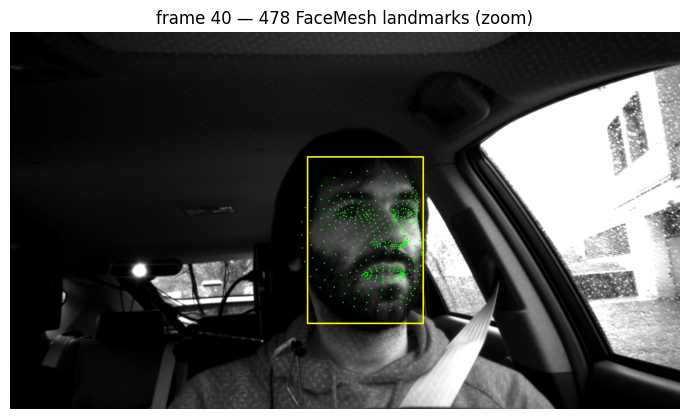

In [5]:
if shots:
    fidx,vis,n = shots[0]
    SAVE = ROOT/"outputs"/"facemesh_view"; SAVE.mkdir(parents=True,exist_ok=True)
    for fidx,vis,n in shots:
        cv2.imwrite(str(SAVE/f"facemesh_frame{fidx}.png"), vis)
    print("saved", len(shots), "images →", SAVE)
    plt.figure(figsize=(7,7)); plt.imshow(cv2.cvtColor(shots[0][1],cv2.COLOR_BGR2RGB))
    plt.title(f"frame {shots[0][0]} — 478 FaceMesh landmarks (zoom)"); plt.axis("off"); plt.tight_layout(); plt.show()

facemesh.close()